In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# GTAA — Signal Research

**Instruments:** SPY (S&P500), EFA (EAFE), IEF (7-10y Treasuries), DBC (commodities), VNQ (REITs). Cash = SHV.
**Signal:** Price > 200-day SMA → long 20%. Price ≤ SMA → cash to SHV.
**Rebalance:** Two variants tested — weekly (Wednesday) and monthly (last business day).
**Execution:** 1-day signal lag (signal at t-1 close, trade at t close).
**Direction:** Long-only, fixed 20% weights per ETF.

**Academic backing:** Meb Faber (2007) "A Quantitative Approach to Tactical Asset Allocation". Updated by Concretum Research QuanTips #1 (April 2025) over 2006-2025 OOS period: Sharpe ~0.68-0.83, CAGR ~5-6%, MaxDD ~12-15%, depending on rebalance day.

**Design decisions:**
- Tranching omitted — it reduces turnover and rebalance-timing luck but slightly hurts Sharpe. Can be added later as cost-reduction optimization.
- 2016 start to match IBS baseline and Alpaca data availability.
- Both weekly and monthly evaluated; if both pass significance, monthly preferred for lower turnover.

**Sizing & implementation** → see `gtaa_Implementation.ipynb`

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
RISK_ETFS   = ["SPY", "EFA", "IEF", "DBC", "VNQ"]
CASH_ETF    = "SHV"
SYMBOLS     = RISK_ETFS + [CASH_ETF]
START_DATE  = "2014-01-01"
END_DATE    = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "GTAA"
SAVE_NAME        = "gtaa"

# Signal params (from Faber 2007)
SMA_WINDOW  = 200
ETF_WEIGHT  = 0.20   # 20% per risk-on ETF, rest to SHV
SIGNAL_LAG  = 1      # 1-day lag between signal and execution

## 2. Data Fetching

In [3]:
data_dict = fetch_historical_data(
    SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

all_data = {}
for sym in SYMBOLS:
    df = data_dict[sym].reset_index()
    df["date"] = pd.to_datetime(df["timestamp"]).dt.tz_localize(None).dt.normalize()
    df = df.set_index("date").sort_index()
    all_data[sym] = df
    print(f"{sym}: {len(df)} bars, {df.index[0].date()} → {df.index[-1].date()}")

Fetching SPY...
  2,575 bars
Fetching EFA...
  2,575 bars
Fetching IEF...
  2,575 bars
Fetching DBC...
  2,575 bars
Fetching VNQ...
  2,575 bars
Fetching SHV...
  2,575 bars
SPY: 2575 bars, 2016-01-04 → 2026-03-31
EFA: 2575 bars, 2016-01-04 → 2026-03-31
IEF: 2575 bars, 2016-01-04 → 2026-03-31
DBC: 2575 bars, 2016-01-04 → 2026-03-31
VNQ: 2575 bars, 2016-01-04 → 2026-03-31
SHV: 2575 bars, 2016-01-04 → 2026-03-31


## 3. Signal Engine

For each ETF, compute 200-day SMA and a binary signal (1 if price > SMA). On each rebalance date, compare current holdings to target weights and emit trades for position changes.

In [4]:
def compute_signals(all_data, sma_window=SMA_WINDOW, signal_lag=SIGNAL_LAG):
    """
    For each risk ETF, compute signal = 1 if close > SMA_{200}, else 0.
    Apply 1-day lag: signal on day t-1 determines position for day t.
    Returns dict[etf] -> DataFrame with columns [close, sma, signal_raw, signal].
    """
    signals = {}
    for sym in RISK_ETFS:
        df = all_data[sym][["close"]].copy()
        df["sma"] = df["close"].rolling(sma_window).mean()
        df["signal_raw"] = (df["close"] > df["sma"]).astype(int)
        df["signal"] = df["signal_raw"].shift(signal_lag)  # 1-day lag
        signals[sym] = df.dropna()
    return signals

def get_rebalance_dates(all_dates, frequency="weekly", weekday=2):
    """
    frequency: 'weekly' or 'monthly'
    weekday: 0=Mon, 2=Wed, 4=Fri (used only for weekly).
    For weekly: pick the first trading day of each week that matches `weekday`, or the next valid trading day.
    For monthly: last trading day of each month.
    """
    all_dates = pd.DatetimeIndex(all_dates).sort_values()
    df = pd.DataFrame({"date": all_dates, "dow": all_dates.weekday,
                        "year": all_dates.year, "month": all_dates.month,
                        "week": all_dates.isocalendar().week.values})
    if frequency == "weekly":
        # For each ISO week, first date >= weekday
        dates = []
        for (y, w), g in df.groupby(["year", "week"]):
            match = g[g["dow"] == weekday]
            if len(match) > 0:
                dates.append(match["date"].iloc[0])
            else:
                # weekday not a trading day that week; take next trading day ≥ weekday
                later = g[g["dow"] >= weekday]
                if len(later) > 0:
                    dates.append(later["date"].iloc[0])
                else:
                    dates.append(g["date"].iloc[-1])
    elif frequency == "monthly":
        # Last trading day of each month
        dates = df.groupby(["year", "month"])["date"].max().tolist()
    else:
        raise ValueError(frequency)
    return pd.DatetimeIndex(sorted(set(dates)))

In [5]:
def generate_trades(all_data, signals, rebalance_dates):
    """
    Walk through rebalance dates. For each ETF, track an open position.
    When signal flips 0→1: open a new trade at that date's close.
    When signal flips 1→0: close the existing trade at that date's close.
    Between rebalance dates, positions are held unchanged (no intra-period trades).

    Returns standardized 9-col trades DataFrame.
    """
    trades = []

    # For each ETF, precompute signal at rebalance dates
    for sym in RISK_ETFS:
        sig_df = signals[sym]
        close_series = all_data[sym]["close"]

        # Signal value on each rebalance date (carried forward from previous day's close)
        rebal_in_range = rebalance_dates[
            (rebalance_dates >= sig_df.index[0]) & (rebalance_dates <= sig_df.index[-1])
        ]
        sig_at_rebal = sig_df["signal"].reindex(rebal_in_range, method="ffill")

        in_pos = False
        entry_price = entry_time = None

        for rd in rebal_in_range:
            if pd.isna(sig_at_rebal.loc[rd]):
                continue
            current_sig = int(sig_at_rebal.loc[rd])
            price_at_rd = close_series.asof(rd)

            if not in_pos and current_sig == 1:
                # Open
                in_pos = True
                entry_price = price_at_rd
                entry_time  = rd
            elif in_pos and current_sig == 0:
                # Close
                exit_price = price_at_rd
                pct_return_gross = (exit_price - entry_price) / entry_price
                trades.append({
                    "entry_time":       entry_time,
                    "exit_time":        rd,
                    "direction":        "long",
                    "instrument":       sym,
                    "entry_price":      round(float(entry_price), 4),
                    "exit_price":       round(float(exit_price), 4),
                    "pct_return_gross": round(float(pct_return_gross), 6),
                    "exit_reason":      "signal_flip",
                    "stop_price":       np.nan,
                })
                in_pos = False

        # Close any open position at end of data
        if in_pos:
            last_date = min(sig_df.index[-1], rebalance_dates[-1])
            exit_price = close_series.asof(last_date)
            if not np.isnan(exit_price):
                pct_return_gross = (exit_price - entry_price) / entry_price
                trades.append({
                    "entry_time":       entry_time,
                    "exit_time":        last_date,
                    "direction":        "long",
                    "instrument":       sym,
                    "entry_price":      round(float(entry_price), 4),
                    "exit_price":       round(float(exit_price), 4),
                    "pct_return_gross": round(float(pct_return_gross), 6),
                    "exit_reason":      "end_of_data",
                    "stop_price":       np.nan,
                })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)

## 4. Run Both Variants: Weekly Wed vs Monthly

For each variant: generate trades, compute gross-of-fees mark-to-market daily equity, run significance tests. Cash return = 0% (simplification; SHV yield is small during most of 2016-2026 but non-trivial in 2022+). Can be added later at PM layer.

In [6]:
signals = compute_signals(all_data)

# All trading dates in the data
all_dates = pd.DatetimeIndex(sorted(set().union(*[all_data[s].index for s in RISK_ETFS])))
print(f"Trading dates: {len(all_dates)}, {all_dates[0].date()} → {all_dates[-1].date()}")

# Rebalance schedules
rebal_weekly = get_rebalance_dates(all_dates, frequency="weekly", weekday=2)   # Wed
rebal_monthly = get_rebalance_dates(all_dates, frequency="monthly")
print(f"\nWeekly rebalance dates: {len(rebal_weekly)}")
print(f"Monthly rebalance dates: {len(rebal_monthly)}")

# Generate trades for both variants
trades_weekly  = generate_trades(all_data, signals, rebal_weekly)
trades_monthly = generate_trades(all_data, signals, rebal_monthly)
print(f"\nWeekly trades: {len(trades_weekly)}")
print(f"  By instrument: {dict(trades_weekly['instrument'].value_counts())}")
print(f"  Avg hold: {(trades_weekly['exit_time'] - trades_weekly['entry_time']).dt.days.mean():.1f} days")

print(f"\nMonthly trades: {len(trades_monthly)}")
print(f"  By instrument: {dict(trades_monthly['instrument'].value_counts())}")
print(f"  Avg hold: {(trades_monthly['exit_time'] - trades_monthly['entry_time']).dt.days.mean():.1f} days")

Trading dates: 2575, 2016-01-04 → 2026-03-31

Weekly rebalance dates: 535
Monthly rebalance dates: 123

Weekly trades: 90
  By instrument: {'DBC': 23, 'VNQ': 21, 'IEF': 17, 'EFA': 17, 'SPY': 12}
  Avg hold: 131.1 days

Monthly trades: 45
  By instrument: {'VNQ': 11, 'EFA': 9, 'DBC': 9, 'IEF': 9, 'SPY': 7}
  Avg hold: 256.8 days


## 5. Mark-to-Market Daily Equity + Significance

Weight per ETF = 20% of total. Cash goes to 0% return (SHV return ignored for simplicity). We build equity as: for each rebalance period, each ETF sleeve gets 20% of capital, either invested (if signal=1) or in cash (if signal=0).

In [7]:
def build_gtaa_daily_equity(trades, all_data, rebalance_dates, starting_capital=STARTING_CAPITAL):
    """
    Build mark-to-market daily equity curve for the GTAA portfolio.
    Approach: per ETF, build a daily return series that is the ETF's daily return
    multiplied by the binary holding indicator (1 when we hold, 0 when in cash).
    Sleeve weight = 20% × daily signal. Portfolio daily return = sum of sleeve daily returns.
    """
    # Reconstruct daily 'am I holding this ETF' indicator from trades
    all_idx = pd.DatetimeIndex(sorted(set().union(*[all_data[s].index for s in RISK_ETFS])))

    sleeve_returns = pd.DataFrame(index=all_idx)
    for sym in RISK_ETFS:
        daily_ret = all_data[sym]["close"].pct_change().reindex(all_idx).fillna(0.0)
        # Build hold indicator: 1 between entry and exit (inclusive of entry, exclusive of exit)
        t_sym = trades[trades["instrument"] == sym]
        hold = pd.Series(0.0, index=all_idx)
        for _, t in t_sym.iterrows():
            mask = (all_idx > t["entry_time"]) & (all_idx <= t["exit_time"])
            hold.loc[mask] = 1.0
        sleeve_returns[sym] = ETF_WEIGHT * hold * daily_ret

    port_daily_returns = sleeve_returns.sum(axis=1)
    eq = starting_capital * (1 + port_daily_returns).cumprod()
    return eq, port_daily_returns, sleeve_returns

eq_w, ret_w, sleeves_w = build_gtaa_daily_equity(trades_weekly,  all_data, rebal_weekly)
eq_m, ret_m, sleeves_m = build_gtaa_daily_equity(trades_monthly, all_data, rebal_monthly)

def _stats(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

s_w = _stats(eq_w, ret_w)
s_m = _stats(eq_m, ret_m)

# SPY benchmark over same window
spy_eq = STARTING_CAPITAL * (1 + all_data["SPY"]["close"].pct_change().fillna(0)).cumprod()
s_spy = _stats(spy_eq, all_data["SPY"]["close"].pct_change())

print(f"\n{'Variant':<20} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 62)
print(f"{'SPY B&H':<20} {s_spy['total_return']:>10,.1f} {s_spy['cagr']:>8.2f} {s_spy['sharpe']:>8.2f} {s_spy['max_dd']:>8.1f}")
print(f"{'GTAA weekly Wed':<20} {s_w['total_return']:>10,.1f} {s_w['cagr']:>8.2f} {s_w['sharpe']:>8.2f} {s_w['max_dd']:>8.1f}")
print(f"{'GTAA monthly':<20} {s_m['total_return']:>10,.1f} {s_m['cagr']:>8.2f} {s_m['sharpe']:>8.2f} {s_m['max_dd']:>8.1f}")


Variant                 TotRet%    CAGR%   Sharpe   MaxDD%
--------------------------------------------------------------
SPY B&H                   279.4    13.91     0.83    -33.8
GTAA weekly Wed            72.8     5.49     0.84    -11.1
GTAA monthly               82.4     6.05     0.92     -8.7


In [8]:
# Significance on each variant
print("=" * 70)
print("SIGNIFICANCE — Weekly Wed")
print("=" * 70)
sig_w = pd.DataFrame({"net_pnl": ret_w.values, "equity_before": 1.0,
                       "position": "long", "direction": "long"})
report_w = full_significance_report(sig_w, strategy_name="GTAA weekly Wed")
print_significance_report(report_w)

print("\n" + "=" * 70)
print("SIGNIFICANCE — Monthly")
print("=" * 70)
sig_m = pd.DataFrame({"net_pnl": ret_m.values, "equity_before": 1.0,
                       "position": "long", "direction": "long"})
report_m = full_significance_report(sig_m, strategy_name="GTAA monthly")
print_significance_report(report_m)

SIGNIFICANCE — Weekly Wed

STATISTICAL SIGNIFICANCE — GTAA weekly Wed

1. t-test (returns > 0)
   Mean return:  0.0221% per trade
   t-statistic:  2.6703
   p-value:      0.003813
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.8355
   95% CI:            [0.2313, 1.4597]
   % below zero:      0.36%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.8355
   p-value:           0.0049
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

SIGNIFICANCE — Monthly

STATISTICAL SIGNIFICANCE — GTAA monthly

1. t-test (returns > 0)
   Mean return:  0.0242% per trade
   t-statistic:  2.9568
   p-value:      0.001568
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.9252
   95% CI:            [0.3135, 1.5583]
   % below zero:      0.19%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.

## 6. Equity Plot

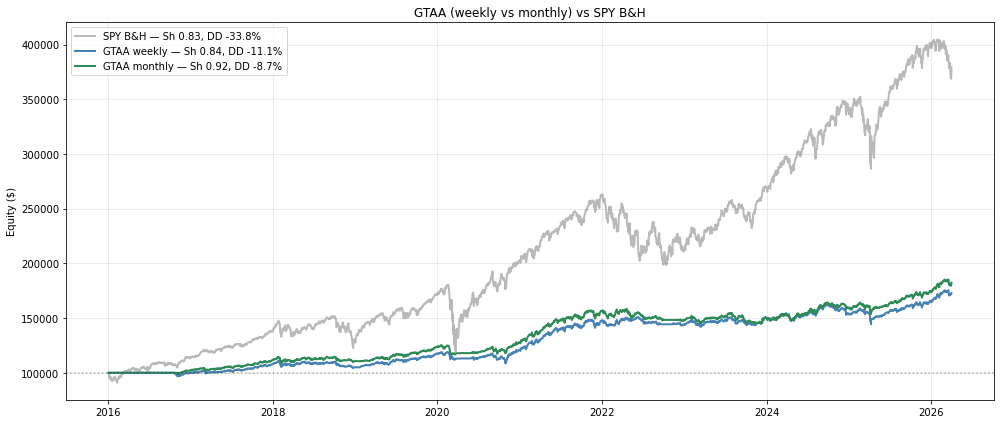

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(spy_eq.index.to_numpy(), spy_eq.values,
        label=f"SPY B&H — Sh {s_spy['sharpe']}, DD {s_spy['max_dd']}%",
        color="gray", alpha=0.55, linewidth=2)
ax.plot(eq_w.index.to_numpy(), eq_w.values,
        label=f"GTAA weekly — Sh {s_w['sharpe']}, DD {s_w['max_dd']}%",
        color="steelblue", linewidth=2)
ax.plot(eq_m.index.to_numpy(), eq_m.values,
        label=f"GTAA monthly — Sh {s_m['sharpe']}, DD {s_m['max_dd']}%",
        color="seagreen", linewidth=2)
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("GTAA (weekly vs monthly) vs SPY B&H")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 7. Per-Instrument Breakdown

In [10]:
print("Per-ETF trade counts and avg hold days:\n")
print(f"{'ETF':<6} {'Weekly Tr':>10} {'Weekly Hold':>13} {'Monthly Tr':>11} {'Monthly Hold':>14}")
print("-" * 60)
for sym in RISK_ETFS:
    tw = trades_weekly[trades_weekly["instrument"] == sym]
    tm = trades_monthly[trades_monthly["instrument"] == sym]
    hw = (tw["exit_time"] - tw["entry_time"]).dt.days.mean() if len(tw) else 0
    hm = (tm["exit_time"] - tm["entry_time"]).dt.days.mean() if len(tm) else 0
    print(f"{sym:<6} {len(tw):>10} {hw:>13.1f} {len(tm):>11} {hm:>14.1f}")

Per-ETF trade counts and avg hold days:

ETF     Weekly Tr   Weekly Hold  Monthly Tr   Monthly Hold
------------------------------------------------------------
SPY            12         241.5           7          404.1
EFA            17         152.7           9          283.7
IEF            17         116.1           9          213.2
DBC            23          89.7           9          216.0
VNQ            21         108.0          11          210.1


## 8. Variant Selection & Save

In [11]:
# Pick winner: monthly preferred unless weekly meaningfully better on Sharpe
# Rationale: monthly has lower turnover (lower fees, simpler operations)
sharpe_lift_weekly = s_w["sharpe"] - s_m["sharpe"]
if sharpe_lift_weekly > 0.10:
    winner = "weekly"
    winner_trades = trades_weekly
    winner_stats = s_w
    winner_report = report_w
    print(f"Winner: WEEKLY (Sharpe {s_w['sharpe']} vs monthly {s_m['sharpe']}, lift +{sharpe_lift_weekly:.2f})")
else:
    winner = "monthly"
    winner_trades = trades_monthly
    winner_stats = s_m
    winner_report = report_m
    print(f"Winner: MONTHLY (Sharpe {s_m['sharpe']} vs weekly {s_w['sharpe']}, lift {-sharpe_lift_weekly:+.2f} — prefer monthly for lower turnover)")

Winner: MONTHLY (Sharpe 0.92 vs weekly 0.84, lift +0.08 — prefer monthly for lower turnover)


In [12]:
import os, json

os.makedirs("results", exist_ok=True)

# Save trades from the winning variant
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
winner_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(winner_trades)} trades → results/{SAVE_NAME}_trades.csv")

# Also save the loser for reference
loser_trades = trades_weekly if winner == "monthly" else trades_monthly
loser_name = "weekly" if winner == "monthly" else "monthly"
loser_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades_{loser_name}.csv", index=False)
print(f"Saved {len(loser_trades)} {loser_name} trades → results/{SAVE_NAME}_trades_{loser_name}.csv (reference)")

# Save daily equity for both variants (useful for Implementation + dashboards)
eq_w.to_csv(f"results/{SAVE_NAME}_daily_equity_weekly.csv")
eq_m.to_csv(f"results/{SAVE_NAME}_daily_equity_monthly.csv")

summary = {
    "strategy": STRATEGY_NAME,
    "instruments": RISK_ETFS + [CASH_ETF],
    "portfolio": "long_term",
    "period": f"{START_DATE} → {END_DATE}",
    "params": {
        "sma_window": SMA_WINDOW, "etf_weight": ETF_WEIGHT,
        "signal_lag": SIGNAL_LAG, "cash_etf": CASH_ETF,
    },
    "param_source": "Faber 2007 + Concretum Research QuanTips #1 (Apr 2025)",
    "winner": winner,
    "variants": {
        "weekly_wed": {"stats": s_w, "trades": len(trades_weekly),
                        "significance": {"sharpe": report_w["bootstrap"]["observed_sharpe"],
                                          "verdict": report_w["verdict"],
                                          "tests_passed": report_w["tests_passed"]}},
        "monthly":    {"stats": s_m, "trades": len(trades_monthly),
                        "significance": {"sharpe": report_m["bootstrap"]["observed_sharpe"],
                                          "verdict": report_m["verdict"],
                                          "tests_passed": report_m["tests_passed"]}},
    },
    "spy_benchmark": s_spy,
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary → results/{SAVE_NAME}_summary.json")
print(f"\nNext: run gtaa_Implementation.ipynb")

Saved 45 trades → results/gtaa_trades.csv
Saved 90 weekly trades → results/gtaa_trades_weekly.csv (reference)
Saved summary → results/gtaa_summary.json

Next: run gtaa_Implementation.ipynb
